# Unshared IRU-ACT (PPO): compute vs. performance

Compute-vs-performance pareto plots for the `lightsout_sweep-ppo_only` wandb project (`fetch_wandb_ppo_only_unshared_iru.py`), restricted to `network.actor_network.pre_torso._target_ == UnsharedIRUAdaptiveComputationTimeTorso` - the only architecture in that project, so there is a single column of results.

Each panel shows final performance vs. final compute steps: fixed-budget points (IQM or median with 95% bootstrap CI over seeds, or mean +/- SEM - see `AGGREGATE`) as plain gray markers, plus one colored diamond for the adaptive[1-16] budget. On the discounted-return panels, dashed lines and a $\Delta$ box compare the adaptive budget against the best uniform budget.

Set `TRIM_N` to drop the N highest- and N lowest-performing seeds from each budget group before averaging (a trimmed mean/SEM), to keep one or two outlier seeds from dominating a group of only ~10.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter, NullLocator
from matplotlib.transforms import blended_transform_factory

import analysis_utils as base

set_size = base.set_size
pgf_with_latex = base.pgf_with_latex
doc_width_pt = base.doc_width_pt

plt.rcParams.update(pgf_with_latex)

# CSV_PATH = "wandb_cache_ppo_only_unshared_iru.csv"
CSV_PATH = "lightsout-iru-final.csv"
OUTPUT_DIR = Path("wandb_plots_ppo_only_unshared_iru")
SAVE_FIGS = True
TRIM_N = 0  # drop this many highest- and lowest-performing seeds per budget group before averaging
N_TAIL_EVALS = 3  # final performance = mean of the last N_TAIL_EVALS eval points
AGGREGATE = "iqm"  # across seeds: "iqm" / "median" (95% bootstrap CI) or "mean" (+/- SEM)
N_BOOTSTRAP = 10000

# Keep only variable-compute (min_steps != max_steps) runs with this
# network.actor_network.pre_torso.halting_temperature / system.halting_ent_coef
# (None = don't filter on it); fixed-budget runs are always kept. Needs a CSV
# fetched with fetch_wandb_lightsout.py's halting_temperature/halting_ent_coef columns.
HALTING_TEMPERATURE = 1
HALTING_ENT_COEF = 0.01

# Local label overrides - "Adaptive compute"/"Uniform compute" read more
# clearly on their own in this single-arch plot.
UNIFORM_LABEL = "Uniform compute"
ADAPTIVE_LABEL = "Variable compute"

In [2]:
df = pd.read_csv(CSV_PATH)
df = df[df["state"] == "finished"]

HALTING_FILTERS = {
    "halting_temperature": HALTING_TEMPERATURE,
    "halting_ent_coef": HALTING_ENT_COEF,
}
# The halting settings only apply to variable compute - a fixed budget
# (min_steps == max_steps) forces the halt, so those runs are always kept.
is_variable = df["min_steps"] != df["max_steps"]
for col, value in HALTING_FILTERS.items():
    if col not in df.columns:
        if value is not None:
            raise KeyError(
                f"{CSV_PATH} has no '{col}' column - re-fetch it with fetch_wandb_lightsout.py "
                f"(which now exports it), or set {col.upper()} = None."
            )
        continue
    if value is None:
        vals = sorted(df.loc[is_variable, col].unique())
        if len(vals) > 1:
            print(f"WARNING: variable-compute {col} takes values {vals} but isn't filtered - the plots average across them.")
        continue
    n_before = df.loc[is_variable, "run_id"].nunique()
    keep = ~is_variable | np.isclose(df[col], value)
    df, is_variable = df[keep], is_variable[keep]
    n_after = df.loc[is_variable, "run_id"].nunique()
    print(f"{col} == {value:g}: kept {n_after}/{n_before} variable-compute runs (fixed-budget runs untouched)")
    if n_after == 0:
        raise ValueError(f"No variable-compute runs left after filtering {col} == {value:g}")

if SAVE_FIGS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SUFFIX = f"_trim{TRIM_N}" if TRIM_N > 0 else ""

print(f"runs={df['run_id'].nunique()}, seeds={df['seed'].nunique()}, trim={TRIM_N}")

halting_temperature == 1: kept 18/38 variable-compute runs (fixed-budget runs untouched)
halting_ent_coef == 0.01: kept 10/18 variable-compute runs (fixed-budget runs untouched)
runs=60, seeds=10, trim=0


## Helpers

`compute_final_values` reduces each run to one number (the tail-average of a metric), `_group_stats` turns a group of seeds into a center and error bar (IQM or median with a bootstrap CI, or mean/SEM, after optional trimming), and `_draw_panel` draws one metric's pareto points onto an axis.

In [3]:
def compute_final_values(df, metric, n_tail=N_TAIL_EVALS):
    """Per-run final performance: mean of the last `n_tail` eval points, plus
    the run's budget so it can be grouped on afterward."""
    tail = df.sort_values("eval_idx").groupby("run_id").tail(n_tail)
    return (
        tail.groupby("run_id")
        .agg(
            value=(metric, "mean"),
            arch=("arch", "first"),
            min_steps=("min_steps", "first"),
            max_steps=("max_steps", "first"),
            sgh=("sgh", "first"),
            vocab_size=("vocab_size", "first"),
            seed=("seed", "first"),
        )
        .reset_index()
    )


def _trim_by_performance(g, trim):
    """Drops the `trim` seeds with the lowest and `trim` seeds with the
    highest `value_perf` from a budget (or adaptive) group, so the
    reported mean/SEM is a trimmed statistic robust to one or two outlier
    seeds. No-op if there aren't enough seeds left over (need > 2*trim)."""
    if trim <= 0 or len(g) <= 2 * trim:
        return g
    return g.sort_values("value_perf").iloc[trim : len(g) - trim]


def aggregate(v, axis=-1):
    """AGGREGATE of v along `axis`. "iqm" is the interquartile mean: the mean of the
    middle 50% after dropping int(n/4) values from each end (scipy.stats.trim_mean(v, 0.25))."""
    v = np.asarray(v, dtype=float)
    if AGGREGATE == "mean":
        return v.mean(axis=axis)
    if AGGREGATE == "median":
        return np.median(v, axis=axis)
    if AGGREGATE == "iqm":
        n = v.shape[axis]
        k = int(0.25 * n)
        return np.take(np.sort(v, axis=axis), np.arange(k, n - k), axis=axis).mean(axis=axis)
    raise ValueError(f"Unknown AGGREGATE {AGGREGATE!r}")


def _center_and_err(v, rng=np.random.default_rng(0)):
    """AGGREGATE of v across seeds plus a [[lower], [upper]] errorbar offset:
    +/- SEM for the mean, percentile-bootstrap 95% CI for median/iqm."""
    n = len(v)
    if AGGREGATE == "mean":
        c = v.mean()
        h = v.std(ddof=1) / np.sqrt(n) if n > 1 else 0.0
        return c, [[h], [h]]
    c = aggregate(v)
    if n <= 1:
        return c, [[0.0], [0.0]]
    boot = aggregate(rng.choice(v, size=(N_BOOTSTRAP, n), replace=True), axis=1)
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return c, [[c - lo], [hi - c]]


def _group_stats(g, trim):
    """(perf_center, perf_err, comp_center, comp_err, n) for one group, after
    trimming (see _trim_by_performance); see _center_and_err."""
    g = _trim_by_performance(g, trim)
    perf_center, perf_err = _center_and_err(g["value_perf"].values)
    comp_center, comp_err = _center_and_err(g["value_compute"].values)
    return perf_center, perf_err, comp_center, comp_err, len(g)


def _draw_panel(ax, df, metric, compute_metric, panel_label, show_ylabel, trim=0):
    """Draws one metric's uniform/adaptive-compute pareto points (plus, for
    the discounted-return metrics, the best-uniform-vs-adaptive delta
    annotation) onto `ax`. `trim` drops the `trim` highest- and
    lowest-performing seeds from each budget (or adaptive) group before averaging
    (see _trim_by_performance)."""
    adaptive_color = sns.color_palette("colorblind", n_colors=3)[0]
    fixed_color = "0.25"

    perf = compute_final_values(df, metric)
    comp = compute_final_values(df, compute_metric)
    merged = perf.merge(comp[["run_id", "value"]], on="run_id", suffixes=("_perf", "_compute"))

    fixed = merged[merged["min_steps"] == merged["max_steps"]]
    fixed_perf_means = {}
    if not fixed.empty:
        for i, (mn, g) in enumerate(sorted(fixed.groupby("min_steps"))):
            perf_mean, perf_err, comp_mean, comp_err, n = _group_stats(g, trim)
            fixed_perf_means[mn] = perf_mean
            ax.errorbar(
                [comp_mean],
                [perf_mean],
                xerr=comp_err,
                yerr=perf_err,
                marker="o",
                markersize=4,
                elinewidth=1,
                color=fixed_color,
                linestyle="none",
                # capsize=1,
                label=UNIFORM_LABEL if i == 0 else None,
            )

    adaptive = merged[merged["min_steps"] != merged["max_steps"]]
    adaptive_perf_mean = None
    if not adaptive.empty:
        perf_mean, perf_err, comp_mean, comp_err, n = _group_stats(adaptive, trim)
        adaptive_perf_mean = perf_mean
        ax.errorbar(
            [comp_mean],
            [perf_mean],
            xerr=comp_err,
            yerr=perf_err,
            marker="x",
            markersize=4,
                elinewidth=1,
            color=adaptive_color,
            linestyle="none",
            # capsize=1,
            label=ADAPTIVE_LABEL,
        )

    if "discounted_return" in metric and fixed_perf_means and adaptive_perf_mean is not None:
        best_uniform_perf = max(fixed_perf_means.values())
        ax.axhline(adaptive_perf_mean, color=adaptive_color, linestyle="--", linewidth=1.0, alpha=0.8)
        ax.axhline(best_uniform_perf, color=fixed_color, linestyle="--", linewidth=1.0, alpha=0.8)
        diff = adaptive_perf_mean - best_uniform_perf
        trans = blended_transform_factory(ax.transAxes, ax.transData)
        ax.text(
            0.95,
            adaptive_perf_mean + 0.05,
            f"$\\Delta$ = {diff:+.3f}",
            transform=trans,
            ha="right",
            va="center",
            fontsize=8,
            alpha=1.0,
            clip_on=False,
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.6", alpha=0.9),
        )

    ax.set_xscale("log", base=2)
    ax.set_xticks([1, 2, 4, 8, 16])
    ax.xaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_major_formatter(FormatStrFormatter("%g"))
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    if panel_label:
        ax.set_title(panel_label)

In [4]:
# Left-to-right panels; PANEL_GROUPS titles are centred over their columns.
PANELS = [
    ("actor/compute_time/mean", "actor/episode_discounted_return/mean", "Disc. return"),
    ("actor/compute_time/mean", "actor/episode_return/mean", "Success rate"),
    ("absolute/compute_time/mean", "absolute/episode_discounted_return/mean", "Disc. return"),
    ("absolute/compute_time/mean", "absolute/episode_return/mean", "Success rate"),
]
PANEL_GROUPS = [("Training", [0, 1]), ("Evaluation", [2, 3])]

# Group titles, legend and x label sit *outside* the set_size figure box (bbox_inches="tight"
# at save time keeps them in the PDF), so the panels get the whole figure height.
XLABEL_OFFSET_IN = 0.19  # x label's bottom edge below the figure box
GROUP_TITLE_GAP_IN = 0.07  # group titles' bottom edge above the figure box
GROUP_TITLE_HEIGHT_IN = 0.2  # room the legend leaves for the group titles

Saved wandb_plots_ppo_only_unshared_iru/analysis-iru.pdf


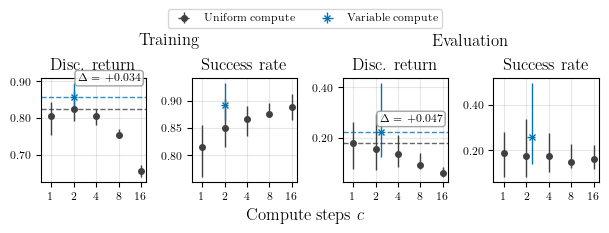

In [5]:
def plot_pareto_row(df, trim=0):
    """1 x len(PANELS) row of pareto panels (see _draw_panel), sharing one
    legend and one x label."""
    ncols = len(PANELS)
    figsize = set_size(doc_width_pt, fraction=0.95, subplots=(1, ncols), use_golden_ratio=False)
    fig, axes = plt.subplots(1, ncols, figsize=figsize, sharex=True, sharey=False)

    for ax, (compute_metric, metric, panel_label) in zip(axes, PANELS):
        _draw_panel(ax, df, metric, compute_metric, panel_label, show_ylabel=False, trim=trim)
    fig.tight_layout(pad=0.2, w_pad=1.0)  # small outer pad: group titles/x label sit right outside

    fig_h = fig.get_figheight()
    fig.supxlabel("Compute steps $c$", y=-XLABEL_OFFSET_IN / fig_h)
    for title, cols in PANEL_GROUPS:
        x0 = min(axes[i].get_position().x0 for i in cols)
        x1 = max(axes[i].get_position().x1 for i in cols)
        fig.text((x0 + x1) / 2, 1 + GROUP_TITLE_GAP_IN / fig_h, title, ha="center", va="bottom", fontsize=12)

    by_label = {}
    for ax in axes:
        for h, l in zip(*ax.get_legend_handles_labels()):
            by_label.setdefault(l, h)
    fig.legend(
        list(by_label.values()),
        list(by_label.keys()),
        bbox_to_anchor=(0.0, 1.0 + (GROUP_TITLE_GAP_IN + GROUP_TITLE_HEIGHT_IN) / fig_h, 1.0, 0.0),
        loc="lower center",
        ncols=len(by_label),
        borderaxespad=0.0,
        frameon=True,
    )
    if SAVE_FIGS:
        output_path = OUTPUT_DIR / "analysis-iru.pdf"
        fig.savefig(output_path, format="pdf", bbox_inches="tight", dpi=600)
        print(f"Saved {output_path}")
    plt.show()


plot_pareto_row(df, trim=TRIM_N)